# Importing Libraries

In [2]:
import os
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing

In [4]:
dataset1 = pd.read_excel('dataset_1.xlsx')

dataset2 = pd.read_excel('dataset_2.xlsx')

dataset3 = pd.read_excel('dataset_3.xlsx')

# printing first few rows of dataset1

In [6]:
dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     610 non-null    int64         
 1   dteday      610 non-null    datetime64[ns]
 2   season      610 non-null    int64         
 3   yr          610 non-null    int64         
 4   mnth        610 non-null    int64         
 5   hr          610 non-null    int64         
 6   holiday     610 non-null    bool          
 7   weekday     610 non-null    int64         
 8   weathersit  610 non-null    int64         
 9   temp        610 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(1), int64(7)
memory usage: 43.6 KB


In [7]:
dataset1.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp
0,1,2011-01-01,1,0,1,0,False,6,1,0.24
1,2,2011-01-01,1,0,1,1,False,6,1,0.22
2,3,2011-01-01,1,0,1,2,False,6,1,0.22
3,4,2011-01-01,1,0,1,3,False,6,1,0.24
4,5,2011-01-01,1,0,1,4,False,6,1,0.24


In [8]:
dataset1.shape

(610, 10)

In [9]:
dataset1.describe()

,instant,dteday,season,yr,mnth,hr,weekday,weathersit,temp
count,610.000000,610,610.0,610.0,610.0,610.000000,610.000000,610.000000,610.000000
mean,305.500000,2011-01-13 19:47:24.590163968,1.0,0.0,1.0,11.795082,2.977049,1.477049,0.196885
min,1.000000,2011-01-01 00:00:00,1.0,0.0,1.0,0.000000,0.000000,1.000000,0.020000
25%,153.250000,2011-01-07 00:00:00,1.0,0.0,1.0,6.000000,1.000000,1.000000,0.160000
50%,305.500000,2011-01-14 00:00:00,1.0,0.0,1.0,12.000000,3.000000,1.000000,0.200000
75%,457.750000,2011-01-21 00:00:00,1.0,0.0,1.0,18.000000,5.000000,2.000000,0.235000
max,610.000000,2011-01-28 00:00:00,1.0,0.0,1.0,23.000000,6.000000,4.000000,0.460000
std,176.236111,NaN,0.0,0.0,0.0,6.852107,2.054943,0.643496,0.081304


In [10]:
dataset1.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
weathersit    0
temp          0
dtype: int64

In [11]:
dataset1.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
605    False
606    False
607    False
608    False
609    False
Length: 610, dtype: bool

Data visulations

 Line Plot for Temporal Trends

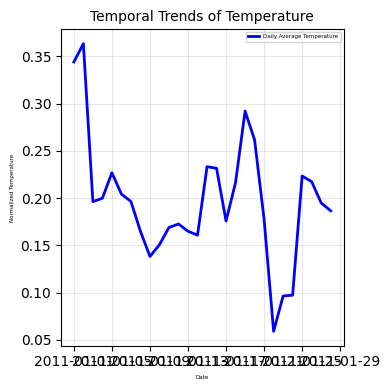

In [14]:
# Convert date column to datetime
dataset1['dteday'] = pd.to_datetime(dataset1['dteday'])

# Group by date to calculate the daily average temperature
daily_avg_temp = dataset1.groupby('dteday')['temp'].mean()

# Plot temporal trends of temperature
plt.figure(figsize=(4,4))
plt.plot(daily_avg_temp.index, daily_avg_temp.values, label='Daily Average Temperature', color='blue', linewidth=2)
plt.title('Temporal Trends of Temperature', fontsize=10)
plt.xlabel('Date', fontsize=4)
plt.ylabel('Normalized Temperature', fontsize=4)
plt.grid(alpha=0.3)
plt.legend(fontsize=4)
plt.tight_layout()
plt.show()

Histogram for Distribution


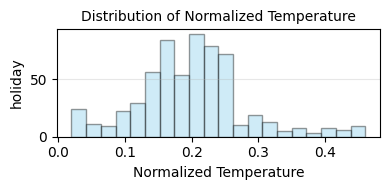

In [16]:
# Plot the distribution of temperature using a histogram

plt.figure(figsize=(4, 2))
plt.hist(dataset1['temp'], bins=20, color='skyblue', edgecolor='black', alpha=0.4)
plt.title('Distribution of Normalized Temperature', fontsize=10)
plt.xlabel('Normalized Temperature', fontsize=10)
plt.ylabel('holiday', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Scatter Plot for Relationships

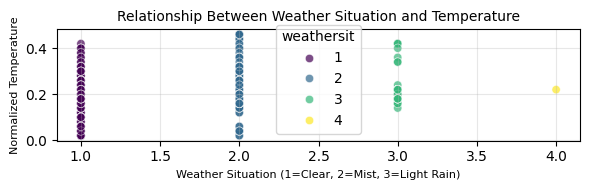

In [18]:
# Scatter plot for temperature vs. weather situation
plt.figure(figsize=(6, 2))
sns.scatterplot(data=dataset1, x='weathersit', y='temp', hue='weathersit', palette='viridis', alpha=0.7)
plt.title('Relationship Between Weather Situation and Temperature', fontsize=10)
plt.xlabel('Weather Situation (1=Clear, 2=Mist, 3=Light Rain)', fontsize=8)
plt.ylabel('Normalized Temperature', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# printing first few rows of dataset2

In [20]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  610 non-null    int64  
 1   instant     610 non-null    int64  
 2   atemp       599 non-null    float64
 3   hum         610 non-null    float64
 4   windspeed   610 non-null    float64
 5   casual      610 non-null    int64  
 6   registered  610 non-null    int64  
 7   cnt         610 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 38.3 KB


In [21]:
dataset2.head()

,Unnamed: 0,instant,atemp,hum,windspeed,casual,registered,cnt
0,0,1,0.2879,0.81,0.0,3,13,16
1,1,2,0.2727,0.80,0.0,8,32,40
2,2,3,0.2727,0.80,0.0,5,27,32
3,3,4,0.2879,0.75,0.0,3,10,13
4,4,5,0.2879,0.75,0.0,0,1,1


In [22]:
dataset2.isnull().sum()

Unnamed: 0     0
instant        0
atemp         11
hum            0
windspeed      0
casual         0
registered     0
cnt            0
dtype: int64

In [23]:
dataset2.duplicated().sum()

0

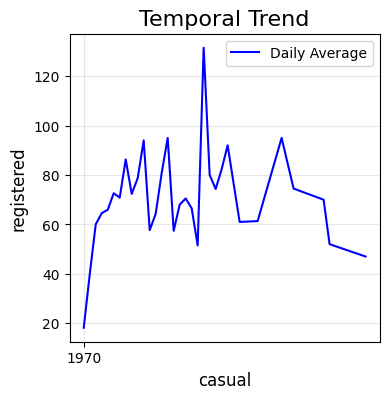

In [24]:
# Convert the date column to datetime
dataset2['casual'] = pd.to_datetime(dataset2['casual'])

# Group by date and compute the average of a column
daily_avg = dataset2.groupby('casual')['registered'].mean()

# Plot
plt.figure(figsize=(4,4))
plt.plot(daily_avg.index, daily_avg.values, color='blue', label='Daily Average')
plt.title('Temporal Trend', fontsize=16)
plt.xlabel('casual', fontsize=12)
plt.ylabel('registered', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

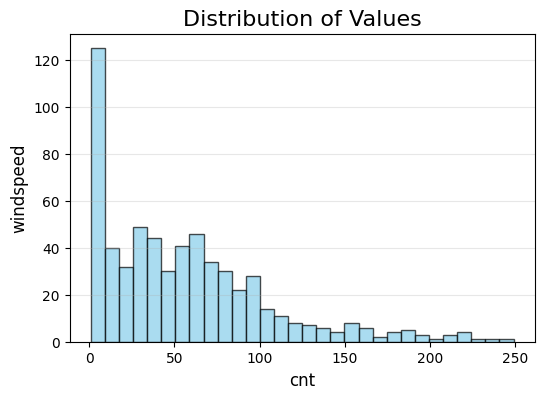

In [25]:
# Plot a histogram for a column
plt.figure(figsize=(6, 4))
plt.hist(dataset2['cnt'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Values', fontsize=16)
plt.xlabel('cnt', fontsize=12)
plt.ylabel('windspeed', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


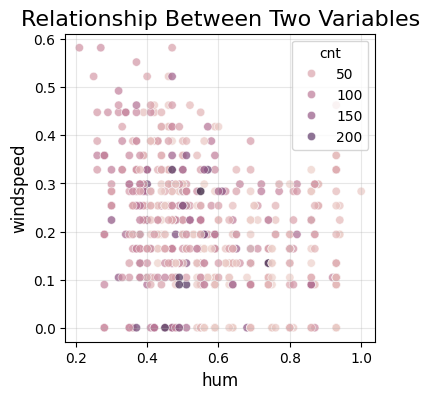

In [26]:
# Scatter plot between two variables
plt.figure(figsize=(4, 4))
sns.scatterplot(data=dataset2, x='hum', y='windspeed', hue='cnt', alpha=0.7)
plt.title('Relationship Between Two Variables', fontsize=16)
plt.xlabel('hum', fontsize=12)
plt.ylabel('windspeed', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Merging of two datasets

In [28]:
merged_1_and_2 = pd.merge(dataset1,dataset2,on='instant',how='inner')

In [29]:
merged_1_and_2

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,Unnamed: 0,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,False,6,1,0.24,0,0.2879,0.81,0.0000,1970-01-01 00:00:00.000000003,13,16
1,2,2011-01-01,1,0,1,1,False,6,1,0.22,1,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000008,32,40
2,3,2011-01-01,1,0,1,2,False,6,1,0.22,2,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000005,27,32
3,4,2011-01-01,1,0,1,3,False,6,1,0.24,3,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000003,10,13
4,5,2011-01-01,1,0,1,4,False,6,1,0.24,4,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,606,2011-01-28,1,0,1,11,False,5,3,0.18,605,0.2121,0.93,0.1045,1970-01-01 00:00:00.000000000,30,30
606,607,2011-01-28,1,0,1,12,False,5,3,0.18,606,0.2121,0.93,0.1045,1970-01-01 00:00:00.000000001,28,29
607,608,2011-01-28,1,0,1,13,False,5,3,0.18,607,0.2121,0.93,0.1045,1970-01-01 00:00:00.000000000,31,31
608,609,2011-01-28,1,0,1,14,False,5,3,0.22,608,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000002,36,38


In [30]:
df1 = dataset1.head()

In [31]:
df2 = dataset2.head(7)

In [32]:
df1

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp
0,1,2011-01-01,1,0,1,0,False,6,1,0.24
1,2,2011-01-01,1,0,1,1,False,6,1,0.22
2,3,2011-01-01,1,0,1,2,False,6,1,0.22
3,4,2011-01-01,1,0,1,3,False,6,1,0.24
4,5,2011-01-01,1,0,1,4,False,6,1,0.24


In [33]:
inner_result = df1.merge(df2,on='instant')

In [34]:
df2

,Unnamed: 0,instant,atemp,hum,windspeed,casual,registered,cnt
0,0,1,0.2879,0.81,0.0000,1970-01-01 00:00:00.000000003,13,16
1,1,2,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000008,32,40
2,2,3,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000005,27,32
3,3,4,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000003,10,13
4,4,5,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000000,1,1
5,5,6,0.2576,0.75,0.0896,1970-01-01 00:00:00.000000000,1,1
6,6,7,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000002,0,2


In [35]:
df1.merge(df2,on='instant',how='left')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,Unnamed: 0,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,False,6,1,0.24,0,0.2879,0.81,0.0,1970-01-01 00:00:00.000000003,13,16
1,2,2011-01-01,1,0,1,1,False,6,1,0.22,1,0.2727,0.80,0.0,1970-01-01 00:00:00.000000008,32,40
2,3,2011-01-01,1,0,1,2,False,6,1,0.22,2,0.2727,0.80,0.0,1970-01-01 00:00:00.000000005,27,32
3,4,2011-01-01,1,0,1,3,False,6,1,0.24,3,0.2879,0.75,0.0,1970-01-01 00:00:00.000000003,10,13
4,5,2011-01-01,1,0,1,4,False,6,1,0.24,4,0.2879,0.75,0.0,1970-01-01 00:00:00.000000000,1,1


In [36]:
df2.merge(df1,on='instant',how='left')

,Unnamed: 0,instant,atemp,hum,windspeed,casual,registered,cnt,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp
0,0,1,0.2879,0.81,0.0000,1970-01-01 00:00:00.000000003,13,16,2011-01-01,1.0,0.0,1.0,0.0,False,6.0,1.0,0.24
1,1,2,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000008,32,40,2011-01-01,1.0,0.0,1.0,1.0,False,6.0,1.0,0.22
2,2,3,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000005,27,32,2011-01-01,1.0,0.0,1.0,2.0,False,6.0,1.0,0.22
3,3,4,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000003,10,13,2011-01-01,1.0,0.0,1.0,3.0,False,6.0,1.0,0.24
4,4,5,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000000,1,1,2011-01-01,1.0,0.0,1.0,4.0,False,6.0,1.0,0.24
5,5,6,0.2576,0.75,0.0896,1970-01-01 00:00:00.000000000,1,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,7,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000002,0,2,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df2['sn']=[i for i in range(7)]

In [38]:
df2.merge(df1,on='instant',how='outer')

,Unnamed: 0,instant,atemp,hum,windspeed,casual,registered,cnt,sn,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp
0,0,1,0.2879,0.81,0.0000,1970-01-01 00:00:00.000000003,13,16,0,2011-01-01,1.0,0.0,1.0,0.0,False,6.0,1.0,0.24
1,1,2,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000008,32,40,1,2011-01-01,1.0,0.0,1.0,1.0,False,6.0,1.0,0.22
2,2,3,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000005,27,32,2,2011-01-01,1.0,0.0,1.0,2.0,False,6.0,1.0,0.22
3,3,4,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000003,10,13,3,2011-01-01,1.0,0.0,1.0,3.0,False,6.0,1.0,0.24
4,4,5,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000000,1,1,4,2011-01-01,1.0,0.0,1.0,4.0,False,6.0,1.0,0.24
5,5,6,0.2576,0.75,0.0896,1970-01-01 00:00:00.000000000,1,1,5,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,7,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000002,0,2,6,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df2

,Unnamed: 0,instant,atemp,hum,windspeed,casual,registered,cnt,sn
0,0,1,0.2879,0.81,0.0000,1970-01-01 00:00:00.000000003,13,16,0
1,1,2,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000008,32,40,1
2,2,3,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000005,27,32,2
3,3,4,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000003,10,13,3
4,4,5,0.2879,0.75,0.0000,1970-01-01 00:00:00.000000000,1,1,4
5,5,6,0.2576,0.75,0.0896,1970-01-01 00:00:00.000000000,1,1,5
6,6,7,0.2727,0.80,0.0000,1970-01-01 00:00:00.000000002,0,2,6


In [40]:
merged_1_and_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     610 non-null    int64         
 1   dteday      610 non-null    datetime64[ns]
 2   season      610 non-null    int64         
 3   yr          610 non-null    int64         
 4   mnth        610 non-null    int64         
 5   hr          610 non-null    int64         
 6   holiday     610 non-null    bool          
 7   weekday     610 non-null    int64         
 8   weathersit  610 non-null    int64         
 9   temp        610 non-null    float64       
 10  Unnamed: 0  610 non-null    int64         
 11  atemp       599 non-null    float64       
 12  hum         610 non-null    float64       
 13  windspeed   610 non-null    float64       
 14  casual      610 non-null    datetime64[ns]
 15  registered  610 non-null    int64         
 16  cnt         610 non-null  

In [41]:
merged_1_and_2.isnull().sum()

instant        0
dteday         0
season         0
yr             0
mnth           0
hr             0
holiday        0
weekday        0
weathersit     0
temp           0
Unnamed: 0     0
atemp         11
hum            0
windspeed      0
casual         0
registered     0
cnt            0
dtype: int64

In [42]:
merged_1_and_2['registered'].mean()

51.06885245901639

In [43]:
merged_1_and_2['temp'].median()

0.2

In [44]:
merged_1_and_2['atemp'].mode()

0    0.197
Name: atemp, dtype: float64

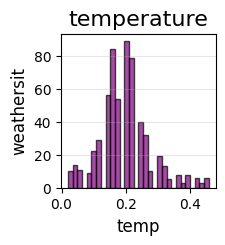

In [45]:
# Plot a histogram for a column
plt.figure(figsize=(2, 2))
plt.hist(merged_1_and_2['temp'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.title('temperature', fontsize=16)
plt.xlabel('temp', fontsize=12)
plt.ylabel('weathersit', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


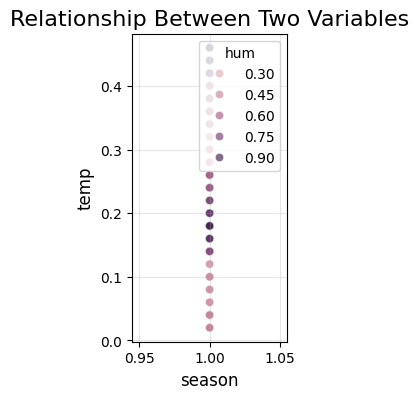

In [46]:
# Scatter plot between two variables
plt.figure(figsize=(2, 4))
sns.scatterplot(merged_1_and_2 , x='season', y='temp', hue='hum', alpha=0.7)
plt.title('Relationship Between Two Variables', fontsize=16)
plt.xlabel('season', fontsize=12)
plt.ylabel('temp', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


In [47]:
dataset3

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,620,2011-01-29,1,0,1,1,False,6,1,0.22,0.2273,0.64,0.1940,0,20,20
1,621,2011-01-29,1,0,1,2,False,6,1,0.22,0.2273,0.64,0.1642,0,15,15
2,622,2011-01-29,1,0,1,3,False,6,1,0.20,0.2121,0.64,0.1343,3,5,8
3,623,2011-01-29,1,0,1,4,False,6,1,0.16,0.1818,0.69,0.1045,1,2,3
4,624,2011-01-29,1,0,1,6,False,6,1,0.16,0.1818,0.64,0.1343,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,615,2011-01-28,1,0,1,20,False,5,2,0.24,0.2273,0.70,0.1940,1,61,62
386,616,2011-01-28,1,0,1,21,False,5,2,0.22,0.2273,0.75,0.1343,1,57,58
387,617,2011-01-28,1,0,1,22,False,5,1,0.24,0.2121,0.65,0.3582,0,26,26
388,618,2011-01-28,1,0,1,23,False,5,1,0.24,0.2273,0.60,0.2239,1,22,23


In [48]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     390 non-null    int64         
 1   dteday      390 non-null    datetime64[ns]
 2   season      390 non-null    int64         
 3   yr          390 non-null    int64         
 4   mnth        390 non-null    int64         
 5   hr          390 non-null    int64         
 6   holiday     390 non-null    bool          
 7   weekday     390 non-null    int64         
 8   weathersit  390 non-null    int64         
 9   temp        390 non-null    float64       
 10  atemp       390 non-null    float64       
 11  hum         390 non-null    float64       
 12  windspeed   390 non-null    float64       
 13  casual      390 non-null    int64         
 14  registered  390 non-null    int64         
 15  cnt         390 non-null    int64         
dtypes: bool(1), datetime64[ns]

In [49]:
dataset3.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,620,2011-01-29,1,0,1,1,False,6,1,0.22,0.2273,0.64,0.1940,0,20,20
1,621,2011-01-29,1,0,1,2,False,6,1,0.22,0.2273,0.64,0.1642,0,15,15
2,622,2011-01-29,1,0,1,3,False,6,1,0.20,0.2121,0.64,0.1343,3,5,8
3,623,2011-01-29,1,0,1,4,False,6,1,0.16,0.1818,0.69,0.1045,1,2,3
4,624,2011-01-29,1,0,1,6,False,6,1,0.16,0.1818,0.64,0.1343,0,2,2


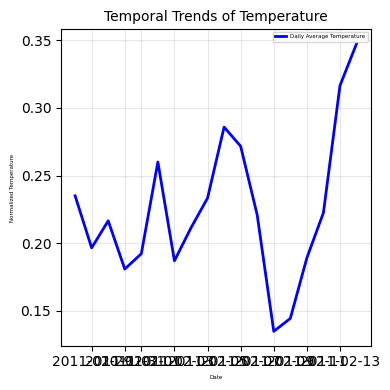

In [50]:
# Convert date column to datetime
dataset1['dteday'] = pd.to_datetime(dataset3['dteday'])

# Group by date to calculate the daily average temperature
daily_avg_temp = dataset3.groupby('dteday')['temp'].mean()

# Plot temporal trends of temperature
plt.figure(figsize=(4,4))
plt.plot(daily_avg_temp.index, daily_avg_temp.values, label='Daily Average Temperature', color='blue', linewidth=2)
plt.title('Temporal Trends of Temperature', fontsize=10)
plt.xlabel('Date', fontsize=4)
plt.ylabel('Normalized Temperature', fontsize=4)
plt.grid(alpha=0.3)
plt.legend(fontsize=4)
plt.tight_layout()
plt.show()

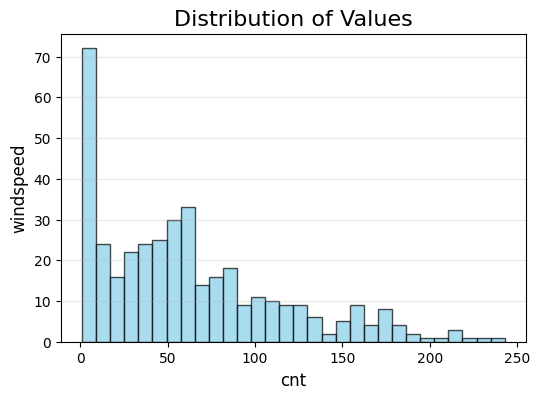

In [51]:
# Plot a histogram for a column
plt.figure(figsize=(6, 4))
plt.hist(dataset3['cnt'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Values', fontsize=16)
plt.xlabel('cnt', fontsize=12)
plt.ylabel('windspeed', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

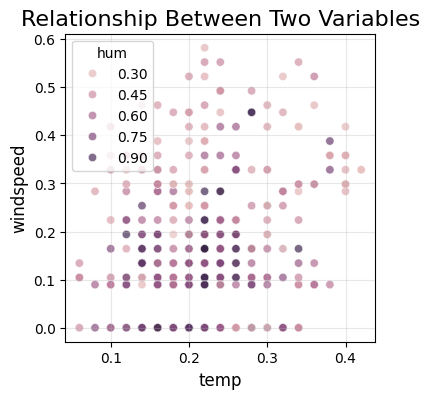

In [52]:
# Scatter plot between two variables
plt.figure(figsize=(4, 4))
sns.scatterplot(data=dataset3, x='temp', y='windspeed', hue='hum', alpha=0.7)  # Replace with actual columns
plt.title('Relationship Between Two Variables', fontsize=16)
plt.xlabel('temp', fontsize=12)
plt.ylabel('windspeed', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


In [53]:
finaldataset= pd.merge(merged_1_and_2, dataset3, on='season', how='inner')  # 'inner', 'left', 'right', or 'outer' joins

print("Merged dataset saved as 'finaldataset.xlsx'")

Merged dataset saved as 'finaldataset.xlsx'


In [54]:
finaldataset

,instant_x,dteday_x,season,yr_x,mnth_x,hr_x,holiday_x,weekday_x,weathersit_x,temp_x,...,holiday_y,weekday_y,weathersit_y,temp_y,atemp_y,hum_y,windspeed_y,casual_y,registered_y,cnt_y
0,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,False,6,1,0.22,0.2273,0.64,0.1940,0,20,20
1,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,False,6,1,0.22,0.2273,0.64,0.1642,0,15,15
2,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,False,6,1,0.20,0.2121,0.64,0.1343,3,5,8
3,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,False,6,1,0.16,0.1818,0.69,0.1045,1,2,3
4,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,False,6,1,0.16,0.1818,0.64,0.1343,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237895,610,2011-01-28,1,0,1,15,False,5,2,0.20,...,False,5,2,0.24,0.2273,0.70,0.1940,1,61,62
237896,610,2011-01-28,1,0,1,15,False,5,2,0.20,...,False,5,2,0.22,0.2273,0.75,0.1343,1,57,58
237897,610,2011-01-28,1,0,1,15,False,5,2,0.20,...,False,5,1,0.24,0.2121,0.65,0.3582,0,26,26
237898,610,2011-01-28,1,0,1,15,False,5,2,0.20,...,False,5,1,0.24,0.2273,0.60,0.2239,1,22,23


In [55]:
rd1 = merged_1_and_2.head()

In [56]:
rd2=dataset3.head()

In [57]:
rd1

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,Unnamed: 0,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,False,6,1,0.24,0,0.2879,0.81,0.0,1970-01-01 00:00:00.000000003,13,16
1,2,2011-01-01,1,0,1,1,False,6,1,0.22,1,0.2727,0.80,0.0,1970-01-01 00:00:00.000000008,32,40
2,3,2011-01-01,1,0,1,2,False,6,1,0.22,2,0.2727,0.80,0.0,1970-01-01 00:00:00.000000005,27,32
3,4,2011-01-01,1,0,1,3,False,6,1,0.24,3,0.2879,0.75,0.0,1970-01-01 00:00:00.000000003,10,13
4,5,2011-01-01,1,0,1,4,False,6,1,0.24,4,0.2879,0.75,0.0,1970-01-01 00:00:00.000000000,1,1


In [58]:
rd2

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,620,2011-01-29,1,0,1,1,False,6,1,0.22,0.2273,0.64,0.1940,0,20,20
1,621,2011-01-29,1,0,1,2,False,6,1,0.22,0.2273,0.64,0.1642,0,15,15
2,622,2011-01-29,1,0,1,3,False,6,1,0.20,0.2121,0.64,0.1343,3,5,8
3,623,2011-01-29,1,0,1,4,False,6,1,0.16,0.1818,0.69,0.1045,1,2,3
4,624,2011-01-29,1,0,1,6,False,6,1,0.16,0.1818,0.64,0.1343,0,2,2


In [180]:
inner_result1=rd1.merge(rd2,on='season')

In [182]:
res = pd.concat([dataset3,merged_1_and_2])

In [61]:
finaldataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237900 entries, 0 to 237899
Data columns (total 32 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   instant_x     237900 non-null  int64         
 1   dteday_x      237900 non-null  datetime64[ns]
 2   season        237900 non-null  int64         
 3   yr_x          237900 non-null  int64         
 4   mnth_x        237900 non-null  int64         
 5   hr_x          237900 non-null  int64         
 6   holiday_x     237900 non-null  bool          
 7   weekday_x     237900 non-null  int64         
 8   weathersit_x  237900 non-null  int64         
 9   temp_x        237900 non-null  float64       
 10  Unnamed: 0    237900 non-null  int64         
 11  atemp_x       233610 non-null  float64       
 12  hum_x         237900 non-null  float64       
 13  windspeed_x   237900 non-null  float64       
 14  casual_x      237900 non-null  datetime64[ns]
 15  registered_x  237

In [62]:
dataset3.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,620,2011-01-29,1,0,1,1,False,6,1,0.22,0.2273,0.64,0.1940,0,20,20
1,621,2011-01-29,1,0,1,2,False,6,1,0.22,0.2273,0.64,0.1642,0,15,15
2,622,2011-01-29,1,0,1,3,False,6,1,0.20,0.2121,0.64,0.1343,3,5,8
3,623,2011-01-29,1,0,1,4,False,6,1,0.16,0.1818,0.69,0.1045,1,2,3
4,624,2011-01-29,1,0,1,6,False,6,1,0.16,0.1818,0.64,0.1343,0,2,2


In [63]:
merged_1_and_2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,weathersit,temp,Unnamed: 0,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,False,6,1,0.24,0,0.2879,0.81,0.0,1970-01-01 00:00:00.000000003,13,16
1,2,2011-01-01,1,0,1,1,False,6,1,0.22,1,0.2727,0.80,0.0,1970-01-01 00:00:00.000000008,32,40
2,3,2011-01-01,1,0,1,2,False,6,1,0.22,2,0.2727,0.80,0.0,1970-01-01 00:00:00.000000005,27,32
3,4,2011-01-01,1,0,1,3,False,6,1,0.24,3,0.2879,0.75,0.0,1970-01-01 00:00:00.000000003,10,13
4,5,2011-01-01,1,0,1,4,False,6,1,0.24,4,0.2879,0.75,0.0,1970-01-01 00:00:00.000000000,1,1


In [64]:
# Merge merged_data with Dataset3
final_merged_data = pd.merge(merged_1_and_2, dataset3, on='cnt', how='inner')  # Replace 'key_column'

# Display the first few rows of the final merged dataset
print(final_merged_data.head())

   instant_x   dteday_x  season_x  yr_x  mnth_x  hr_x  holiday_x  weekday_x  \
0          1 2011-01-01         1     0       1     0      False          6   
1          1 2011-01-01         1     0       1     0      False          6   
2        163 2011-01-08         1     0       1     1      False          6   
3        163 2011-01-08         1     0       1     1      False          6   
4        164 2011-01-08         1     0       1     2      False          6   

   weathersit_x  temp_x  ...  hr_y  holiday_y  weekday_y  weathersit_y temp_y  \
0             1    0.24  ...    23      False          2             3   0.20   
1             1    0.24  ...     0      False          4             3   0.14   
2             2    0.18  ...    23      False          2             3   0.20   
3             2    0.18  ...     0      False          4             3   0.14   
4             2    0.18  ...    23      False          2             3   0.20   

   atemp_y  hum_y  windspeed_y casual_

In [65]:
# Save the final merged dataset to an Excel file
final_merged_data.to_excel('final_merged_dataset.xlsx', index=False)
print("Final merged dataset saved as 'final_merged_dataset.xlsx'")

Final merged dataset saved as 'final_merged_dataset.xlsx'


In [66]:
pd.merge(merged_1_and_2,dataset3, on='cnt', how='inner', suffixes=('_merged', '_dataset3'))

,instant_merged,dteday_merged,season_merged,yr_merged,mnth_merged,hr_merged,holiday_merged,weekday_merged,weathersit_merged,temp_merged,...,hr_dataset3,holiday_dataset3,weekday_dataset3,weathersit_dataset3,temp_dataset3,atemp_dataset3,hum_dataset3,windspeed_dataset3,casual_dataset3,registered_dataset3
0,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,23,False,2,3,0.20,0.1970,0.93,0.1940,1,15
1,1,2011-01-01,1,0,1,0,False,6,1,0.24,...,0,False,4,3,0.14,0.1364,0.86,0.1940,0,16
2,163,2011-01-08,1,0,1,1,False,6,2,0.18,...,23,False,2,3,0.20,0.1970,0.93,0.1940,1,15
3,163,2011-01-08,1,0,1,1,False,6,2,0.18,...,0,False,4,3,0.14,0.1364,0.86,0.1940,0,16
4,164,2011-01-08,1,0,1,2,False,6,2,0.18,...,23,False,2,3,0.20,0.1970,0.93,0.1940,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438,579,2011-01-26,1,0,1,9,False,3,3,0.22,...,14,False,3,1,0.20,0.1818,0.34,0.2985,2,56
2439,579,2011-01-26,1,0,1,9,False,3,3,0.22,...,21,False,5,2,0.22,0.2273,0.75,0.1343,1,57
2440,514,2011-01-23,1,0,1,12,False,0,1,0.16,...,9,False,2,2,0.16,0.2273,0.93,0.0000,2,114
2441,564,2011-01-25,1,0,1,16,False,2,2,0.32,...,9,False,2,2,0.16,0.2273,0.93,0.0000,2,114


In [67]:
# Inspect the final merged dataset
print(final_merged_data.head())
print(final_merged_data.info())
print(final_merged_data.describe())

   instant_x   dteday_x  season_x  yr_x  mnth_x  hr_x  holiday_x  weekday_x  \
0          1 2011-01-01         1     0       1     0      False          6   
1          1 2011-01-01         1     0       1     0      False          6   
2        163 2011-01-08         1     0       1     1      False          6   
3        163 2011-01-08         1     0       1     1      False          6   
4        164 2011-01-08         1     0       1     2      False          6   

   weathersit_x  temp_x  ...  hr_y  holiday_y  weekday_y  weathersit_y temp_y  \
0             1    0.24  ...    23      False          2             3   0.20   
1             1    0.24  ...     0      False          4             3   0.14   
2             2    0.18  ...    23      False          2             3   0.20   
3             2    0.18  ...     0      False          4             3   0.14   
4             2    0.18  ...    23      False          2             3   0.20   

   atemp_y  hum_y  windspeed_y casual_

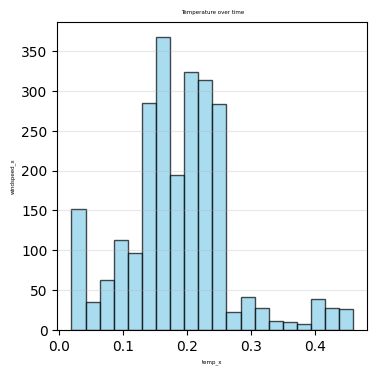

In [68]:
# Plot a histogram for a numeric column
plt.figure(figsize=(4, 4))
plt.hist(final_merged_data['temp_x'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Temperature over time', fontsize=4)
plt.xlabel('temp_x', fontsize=4)
plt.ylabel('windspeed_x', fontsize=4)
plt.grid(axis='y', alpha=0.3)
plt.show()

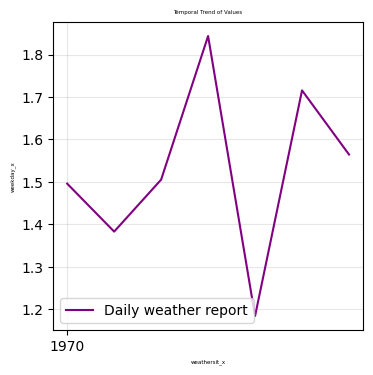

In [69]:
# Convert the date column to datetime
final_merged_data['weekday_x'] = pd.to_datetime(final_merged_data['weekday_x'])

# Group by date to calculate daily averages
daily_avg = final_merged_data.groupby('weekday_x')['weathersit_x'].mean()

# Plot temporal trends
plt.figure(figsize=(4, 4))
plt.plot(daily_avg.index, daily_avg.values, color='purple', label='Daily weather report')
plt.title('Temporal Trend of Values', fontsize=4)
plt.xlabel('weathersit_x', fontsize=4)
plt.ylabel('weekday_x', fontsize=4)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

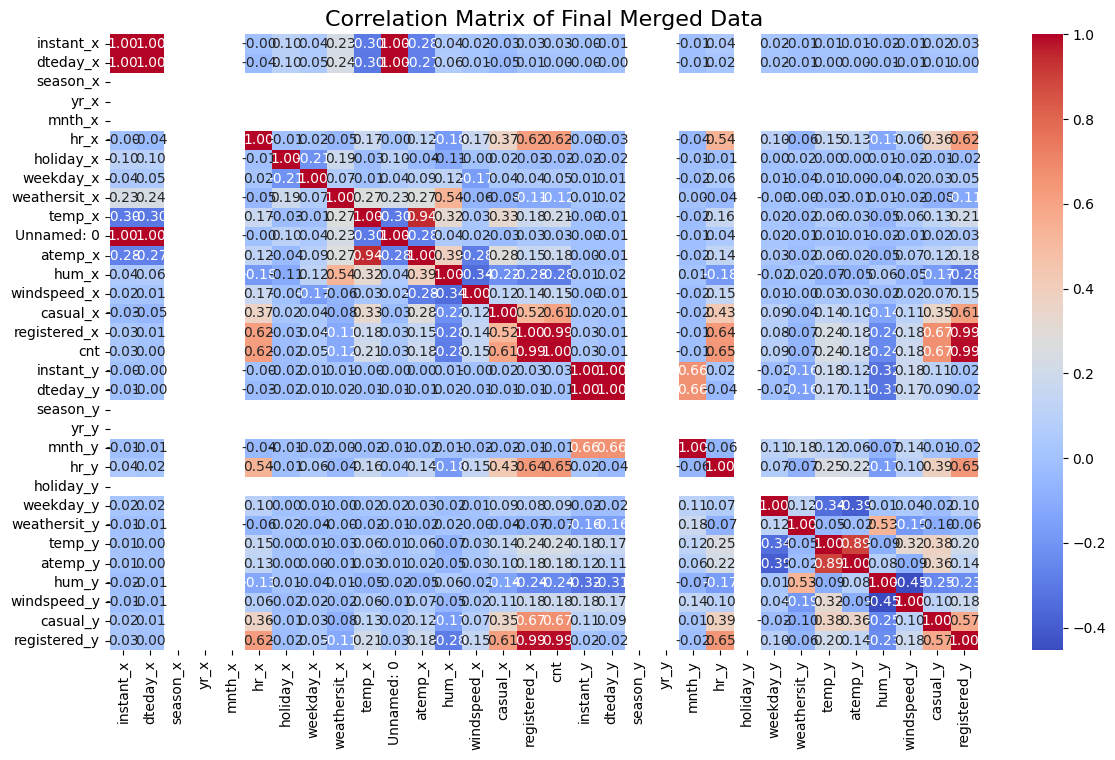

In [70]:
# Compute the correlation matrix
correlation_matrix = final_merged_data.corr()

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Final Merged Data', fontsize=16)
plt.show()

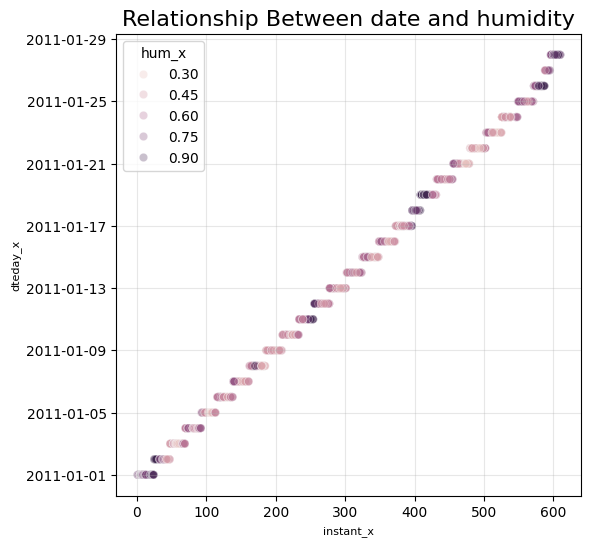

In [71]:
# Scatter plot between two columns
plt.figure(figsize=(6, 6))
sns.scatterplot(data=final_merged_data, x='instant_x', y='dteday_x', hue='hum_x', alpha=0.3)
plt.title('Relationship Between date and humidity', fontsize=16)
plt.xlabel('instant_x', fontsize=8)
plt.ylabel('dteday_x', fontsize=8)
plt.grid(alpha=0.3)
plt.show()

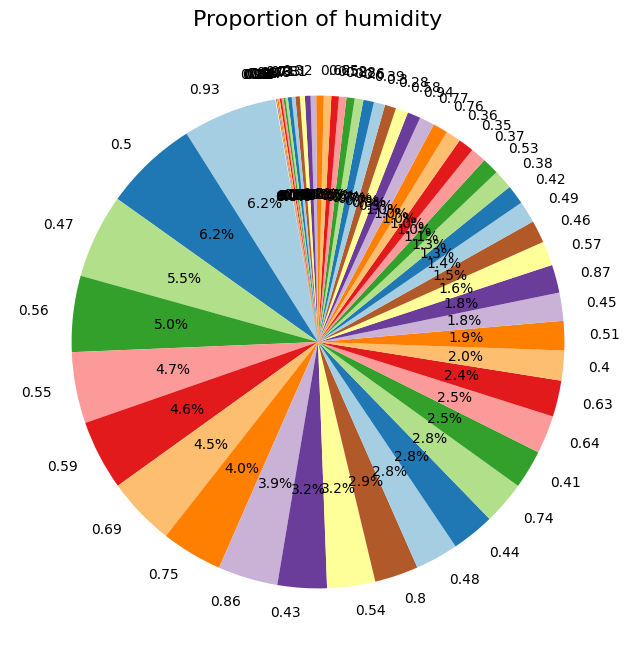

In [72]:
# Aggregate data for a categorical column
category_counts = final_merged_data['hum_x'].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=100, colors=plt.cm.Paired.colors)
plt.title('Proportion of humidity', fontsize=16)
plt.show()

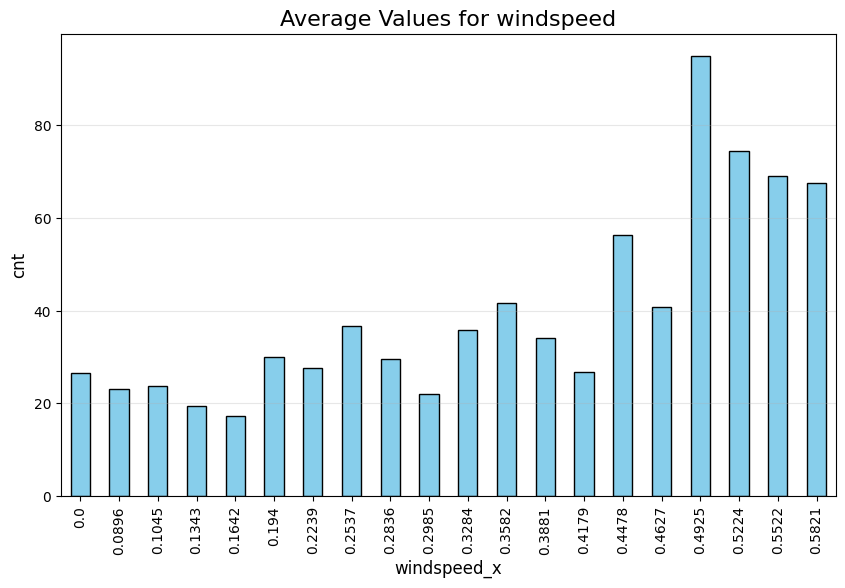

In [73]:
# Group by a category and calculate averages
category_avg = final_merged_data.groupby('windspeed_x')['cnt'].mean()

# Plot a bar chart
category_avg.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Average Values for windspeed', fontsize=16)
plt.xlabel('windspeed_x', fontsize=12)
plt.ylabel('cnt', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

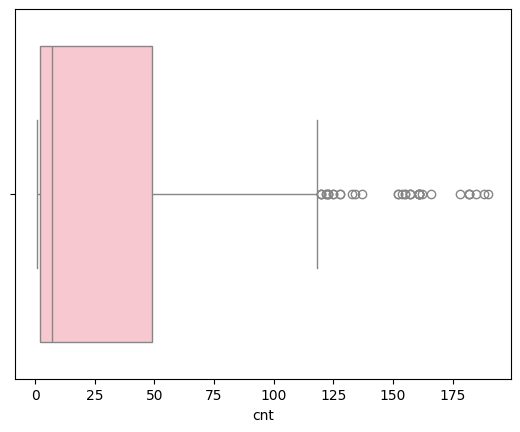

In [74]:
sns.boxplot(x='cnt',data=final_merged_data,color='pink')
plt.show

In [75]:
# Normal Distribution

In [76]:
mean = final_merged_data['temp_x'].mean()

In [77]:
mean

0.18446172738436348

In [78]:
stnd_deviation = final_merged_data['hum_x'].std()

In [79]:
stnd_deviation

0.17013291858143736

In [186]:
max_value = final_merged_data['temp_x'].mean() + 3*final_merged_data['temp_x'].std()
min_value = final_merged_data['temp_x'].mean() - 3*final_merged_data['temp_x'].std()

In [188]:
min_value

-0.05857622557370604

In [190]:
max_value

0.427499680342433

Finding the Outliers

In [192]:
new_final_merged_data= final_merged_data[(final_merged_data['temp_x']>0.264) | (final_merged_data['temp_x']<0.20)]

In [194]:
new_final_merged_data

,instant_x,dteday_x,season_x,yr_x,mnth_x,hr_x,holiday_x,weekday_x,weathersit_x,temp_x,...,hr_y,holiday_y,weekday_y,weathersit_y,temp_y,atemp_y,hum_y,windspeed_y,casual_y,registered_y
2,163,2011-01-08,1,0,1,1,False,1970-01-01 00:00:00.000000006,2,0.18,...,23,False,2,3,0.20,0.1970,0.93,0.1940,1,15
3,163,2011-01-08,1,0,1,1,False,1970-01-01 00:00:00.000000006,2,0.18,...,0,False,4,3,0.14,0.1364,0.86,0.1940,0,16
4,164,2011-01-08,1,0,1,2,False,1970-01-01 00:00:00.000000006,2,0.18,...,23,False,2,3,0.20,0.1970,0.93,0.1940,1,15
5,164,2011-01-08,1,0,1,2,False,1970-01-01 00:00:00.000000006,2,0.18,...,0,False,4,3,0.14,0.1364,0.86,0.1940,0,16
6,260,2011-01-12,1,0,1,6,False,1970-01-01 00:00:00.000000003,1,0.12,...,23,False,2,3,0.20,0.1970,0.93,0.1940,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2435,512,2011-01-23,1,0,1,10,False,1970-01-01 00:00:00.000000000,1,0.14,...,14,False,3,1,0.20,0.1818,0.34,0.2985,2,56
2436,512,2011-01-23,1,0,1,10,False,1970-01-01 00:00:00.000000000,1,0.14,...,21,False,5,2,0.22,0.2273,0.75,0.1343,1,57
2440,514,2011-01-23,1,0,1,12,False,1970-01-01 00:00:00.000000000,1,0.16,...,9,False,2,2,0.16,0.2273,0.93,0.0000,2,114
2441,564,2011-01-25,1,0,1,16,False,1970-01-01 00:00:00.000000002,2,0.32,...,9,False,2,2,0.16,0.2273,0.93,0.0000,2,114


In [196]:
final_merged_data.shape

(2443, 32)

In [198]:
after_removing_outliers = final_merged_data[(final_merged_data['temp_x']<0.02) & (final_merged_data['temp_x']>0.24)]

In [200]:
after_removing_outliers

,instant_x,dteday_x,season_x,yr_x,mnth_x,hr_x,holiday_x,weekday_x,weathersit_x,temp_x,...,hr_y,holiday_y,weekday_y,weathersit_y,temp_y,atemp_y,hum_y,windspeed_y,casual_y,registered_y


In [89]:
#capping

In [202]:
max_value

0.427499680342433

In [204]:
min_value

-0.05857622557370604

In [206]:
final_merged_data['temp_x'] = np.where(
    final_merged_data['temp_x']> max_value,
    max_value,
    
    np.where(
        final_merged_data['temp_x']<min_value,
        min_value,
        
        final_merged_data['temp_x'] ))

Text(0, 0.5, 'temp')

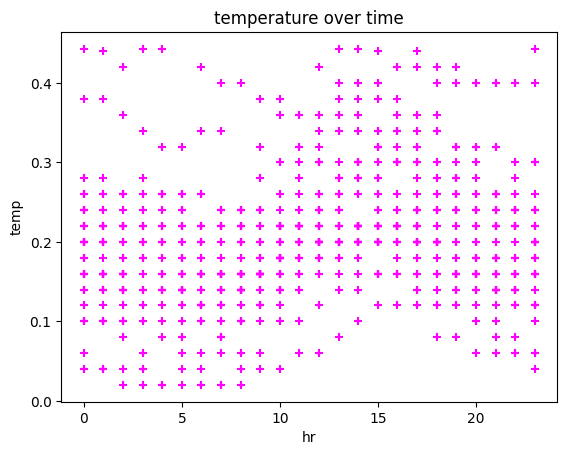

In [94]:
plt.scatter(res['hr'],res['temp'],color = '#FF00FF',marker='+')
plt.title('temperature over time')
plt.xlabel('hr')
plt.ylabel('temp')
#plt.legend(["hr", "temp"], loc="upper left")